# Voice Interaction

by Tobias Erbacher

Let's import the libraries necessary to run this notebook. However, the audio libraries (recording, playback) that can be used in Colab or locally differ, and some of the TTS-models cannot be run on CPU-only systems. So we will programmatically check in which environment this notebook is run.

In [1]:
import os
RUNNING_ON_LOCAL_MACHINE = True if 'COLAB_GPU' not in os.environ else False

import torch
GPU_AVAILABLE = torch.cuda.is_available()

!pip install openai-whisper pyttsx3

if RUNNING_ON_LOCAL_MACHINE:
  !pip install sounddevice pynput
  from pynput import keyboard
  if GPU_AVAILABLE:
    !pip install inflect
else:
  !apt-get install -y portaudio19-dev
  !pip install sounddevice unidecode inflect ffmpeg-python
  !sudo apt-get install texlive texlive-latex-extra dvipng cm-super -y
  from IPython.display import HTML, Audio, display
  from google.colab.output import eval_js
  from base64 import b64decode
  from scipy.io.wavfile import read as wav_read
  import io
  import ffmpeg
  import ipywidgets as widgets
  from google.colab import output

import math
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import time
import sounddevice as sd
import threading

# Speech-to-Text
import librosa
from scipy.io.wavfile import write
import queue
import whisper

# Text-to-Speech
import pyttsx3 # Model 1

if GPU_AVAILABLE:
  import unidecode # Model 2
  import inflect

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-1.1).
texlive is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


---

In [2]:
AVAILABLE_TTS_MODELS = {
    "OPENAI-WHISPER-BASE" : 0,
}

AVAILABLE_STT_MODELS = {
    "PYTTSX3" : 0,
    "TACOTRON2" : 1,
}

### Speech-to-Text

In [3]:
MAX_DURATION = 30                               # Maximum audio recording duration in seconds.
SAVE_AUDIO = False                              # True: Audio will be saved after recording; False: Audio will not be saved after recording.
OUTPUT_FILENAME = "speech_input.wav"            # Name of the audio file that will be saved. Remember to give it a filetype, i.e. ".wav" at the end.
PLAY_AFTER_RECORDING = False                    # Do you wish to replay the audio after the recording?

In [4]:
SAMPLING_RATE = 16000                           # Hz. Note that openai whisper requires 160000 Hz
NUMBER_OF_RECORDING_CHANNELS = 1                # Number of channels (1 for mono, 2 for stereo). Note that openai whisper requires mono channel.

WAVEFORM_PARAMS = {                             # Plot parameters for the wave form.
    'figure.figsize': (16, 6),
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'grid.alpha': 0.5,
    'legend.fontsize': 12,
    #'legend.frameon': False,
    'axes.grid': True,
    'axes.labelsize': 12,
    'lines.linewidth': 0.5,
    # Font settings for LaTeX
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
}

MEL_SPECTROGRAM_WINDOW_SIZE = 0.025             # Mel spectrogram window size in seconds.
MEL_SPECTROGRAM_HOP_SIZE = 0.01                 # Mel spectrogram hop size (delay between consecutive windows) in seconds.
MEL_SPECTROGRAM_START_TIME = 0                  # Mel spectrogram start time in seconds.
N_FFT = 1300                                    # Mel spectrogram sample number for Fast Fourier Transform.
N_MEL = 80                                      # Mel spectrogram band number to generate.

MEL_SPECTROGRAM_PARAMS = {                      # Plot parameters for the wave form.
    'figure.figsize': (16, 6),
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'grid.alpha': 0.5,
    'legend.fontsize': 12,
    #'legend.frameon': False,
    'axes.grid': True,
    'axes.labelsize': 12,
    'lines.linewidth': 0.5,
    # Font settings for LaTeX
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
}

In [5]:
# Only relevant for non-local environments.
AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_p = document.createElement("P");
var my_btn = document.createElement("BUTTON");
var t = document.createTextNode("Press to start recording");

my_btn.appendChild(t);
//my_p.appendChild(my_btn);
my_div.appendChild(my_btn);
document.body.appendChild(my_div);

var base64data = 0;
var reader;
var recorder, gumStream;
var recordButton = my_btn;

var handleSuccess = function(stream) {
  gumStream = stream;
  var options = {
    //bitsPerSecond: 8000, //chrome seems to ignore, always 48k
    mimeType : 'audio/webm;codecs=opus'
    //mimeType : 'audio/webm;codecs=pcm'
  };
  //recorder = new MediaRecorder(stream, options);
  recorder = new MediaRecorder(stream);
  recorder.ondataavailable = function(e) {
    var url = URL.createObjectURL(e.data);
    var preview = document.createElement('audio');
    preview.controls = true;
    preview.src = url;
    document.body.appendChild(preview);

    reader = new FileReader();
    reader.readAsDataURL(e.data);
    reader.onloadend = function() {
      base64data = reader.result;
      //console.log("Inside FileReader:" + base64data);
    }
  };
  recorder.start();
  };

recordButton.innerText = "Recording... press to stop";

navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess);


function toggleRecording() {
  if (recorder && recorder.state == "recording") {
      recorder.stop();
      gumStream.getAudioTracks()[0].stop();
      recordButton.innerText = "Saving the recording... pls wait!"
  }
}

// https://stackoverflow.com/a/951057
function sleep(ms) {
  return new Promise(resolve => setTimeout(resolve, ms));
}

var data = new Promise(resolve=>{
//recordButton.addEventListener("click", toggleRecording);
recordButton.onclick = ()=>{
toggleRecording()

sleep(2000).then(() => {
  // wait 2000ms for the data to be available...
  // ideally this should use something like await...
  //console.log("Inside data:" + base64data)
  resolve(base64data.toString())

});

}
});

</script>
"""

First we need to set up the audio recorder. We do this with an InputStream and a buffer. Execute the cell and speak. To stop the recording, press the space bar.

In [6]:
audio_recording_queue = queue.Queue()
stop_recording = False

audio_recording_buffer = []

def audio_callback(input_data, frames, time, status): # Do not remove the not needed parameters as they are somehow used in the InputStream
  if status:
    print(status)
  audio_recording_queue.put(input_data.copy())

AUDIO_RECORDING_START_TIME = time.time()

if RUNNING_ON_LOCAL_MACHINE:
  def on_press(key):
    global stop_recording
    if key == keyboard.Key.space:
      stop_recording = True
      key_listener.stop()
      print("Recording has been stopped by the user.")

  with sd.InputStream(samplerate=SAMPLING_RATE, channels=NUMBER_OF_RECORDING_CHANNELS, callback=audio_callback):
    key_listener = keyboard.Listener(on_press=on_press)
    key_listener.start()

    while not stop_recording:
      if time.time() - AUDIO_RECORDING_START_TIME < MAX_DURATION:
        audio_recording_buffer.append(audio_recording_queue.get())
      else:
        print("Recording has been stopped due to maximum length.")
        key_listener.stop()
        break
  AUDIO_RECORDING_FORMATTED = np.concatenate(audio_recording_buffer, axis=0).squeeze()
  VOICE_INPUT = AUDIO_RECORDING_FORMATTED / np.max(np.abs(AUDIO_RECORDING_FORMATTED))
else:
  # THIS IS ADAPTED FROM THE TA's NOTEBOOK "4_Speech.ipynb"
  def audio_recorder():
    global SAMPLING_RATE
    display(HTML(AUDIO_HTML))
    RECORDING = eval_js("data")
    BINARY_RECORDING = b64decode(RECORDING.split(',')[1])

    process = (ffmpeg
      .input('pipe:0')
      .output('pipe:1', format='wav', ar=SAMPLING_RATE)
      .run_async(pipe_stdin=True, pipe_stdout=True, pipe_stderr=True, quiet=True, overwrite_output=True)
    )
    output, err = process.communicate(input=BINARY_RECORDING)

    RIFF_CHUNK_SIZE = len(output) - 8
    Q = RIFF_CHUNK_SIZE
    b = []
    for i in range(4):
      Q, R = divmod(Q, 256)
      b.append(R)

    RIFF = output[:4] + bytes(b) + output[8:]

    AUDIO_DATA = io.BytesIO(RIFF)
    SAMPLING_RATE, AUDIO = wav_read(AUDIO_DATA)
    VOICE_INPUT = torch.tensor(AUDIO / np.max(np.abs(AUDIO)), dtype=torch.float32)

    return VOICE_INPUT, SAMPLING_RATE

  VOICE_INPUT, SAMPLING_RATE = audio_recorder()


In [7]:
if SAVE_AUDIO:
  write(OUTPUT_FILENAME, SAMPLING_RATE, (VOICE_INPUT * 32767).astype(np.int16))

if PLAY_AFTER_RECORDING and not RUNNING_ON_LOCAL_MACHINE:
  Audio(VOICE_INPUT, rate=SAMPLING_RATE)

Now that we have recorded the audio, we can put it into a speech-to-text model of our choice. We start with the openai-whisper models:

In [8]:
if GPU_AVAILABLE:
  model = whisper.load_model("base").to("cuda")
else:
  model = whisper.load_model("base")

/usr/local/lib/python3.10/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_location=device)


Next, we can detect what language was spoken:

In [9]:
_, LANGUAGE_PROBABILITIES = model.detect_language(whisper.log_mel_spectrogram(whisper.pad_or_trim(VOICE_INPUT)).to(device=model.device))
DETECTED_LANGUAGE = max(LANGUAGE_PROBABILITIES, key=LANGUAGE_PROBABILITIES.get)
print("Detected language: " + str(DETECTED_LANGUAGE) + ", confidence: " + str(round(LANGUAGE_PROBABILITIES[DETECTED_LANGUAGE] * 100, 2)))

Detected language: en, confidence: 90.52


Thereupon, we transform the audio to text.

In [10]:
TEXT = model.transcribe(VOICE_INPUT)["text"]

/usr/local/lib/python3.10/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [11]:
TEXT

' Test test test 1 2 3 is just working test test test'

### Speech-to-Text Analytics

If you wish to perform some analytics on the recorded voice input, you can run the following cells. First, you can take a look at the wave form.

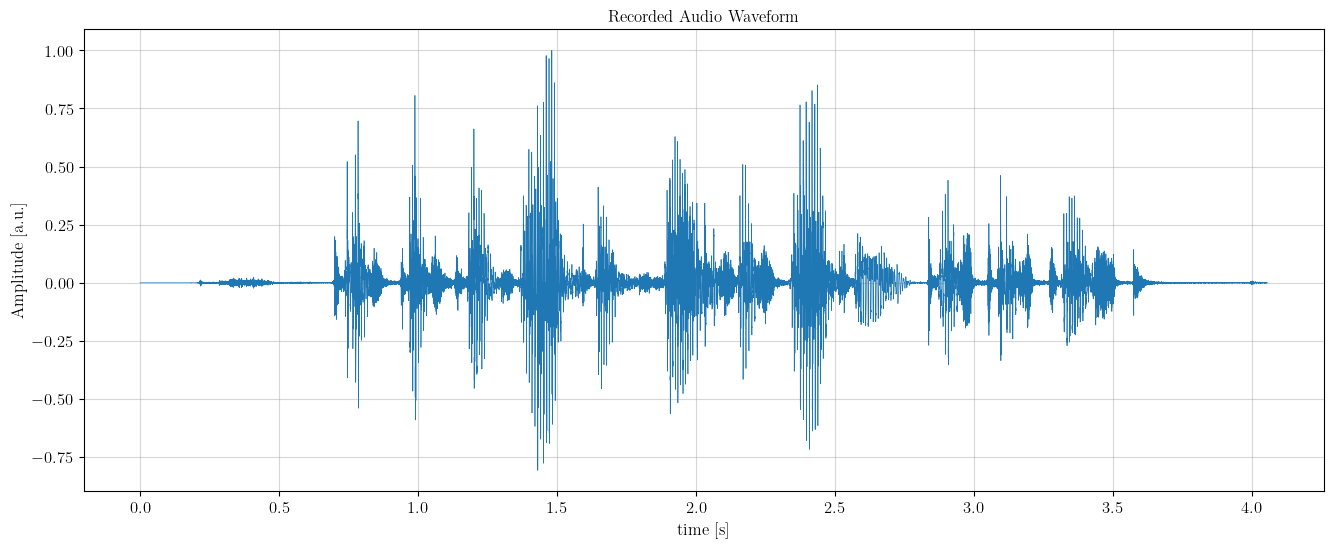

In [12]:
DURATION = VOICE_INPUT.shape[0] / SAMPLING_RATE
TIME = np.linspace(0, DURATION, VOICE_INPUT.shape[0])

mpl.rcParams.update(WAVEFORM_PARAMS)
plt.plot(TIME, VOICE_INPUT)
plt.title("Recorded Audio Waveform")
plt.xlabel("time [s]")
plt.ylabel("Amplitude [a.u.]")
plt.show()

Next up, we can plot the Mel-spectrogram:

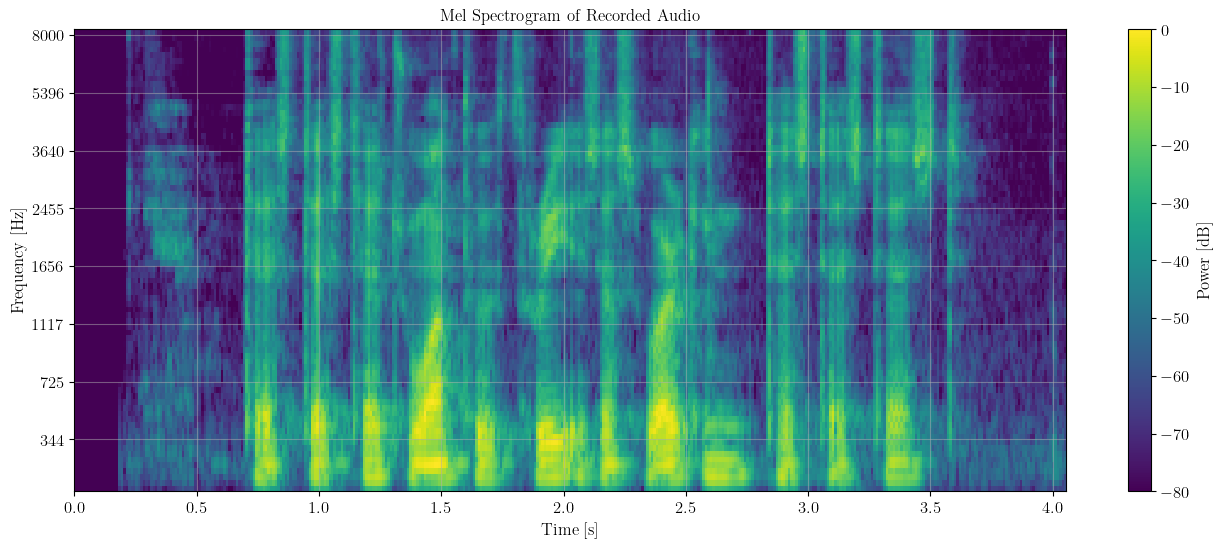

In [13]:
W = int(math.ceil(MEL_SPECTROGRAM_WINDOW_SIZE * SAMPLING_RATE))
D = int(math.ceil(MEL_SPECTROGRAM_HOP_SIZE * SAMPLING_RATE))
T = int(math.ceil(MEL_SPECTROGRAM_START_TIME * SAMPLING_RATE))

if not RUNNING_ON_LOCAL_MACHINE:
  VOICE_INPUT = VOICE_INPUT.numpy()

MEL_SPECTROGRAM = librosa.feature.melspectrogram(y=VOICE_INPUT, sr=SAMPLING_RATE, n_fft=N_FFT, win_length=W, hop_length=D, n_mels=N_MEL).squeeze()

MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES = np.arange(MEL_SPECTROGRAM.shape[0] + 1)
MEL_SPECTROGRAM_TIME_SLICES = np.linspace(0, DURATION, MEL_SPECTROGRAM.shape[1] + 1)
MEL_SPECTROGRAM_POWER = librosa.power_to_db(MEL_SPECTROGRAM, ref=np.max)

MEL_FREQUENCIES = np.append(librosa.mel_frequencies(n_mels=N_MEL, fmax=SAMPLING_RATE / 2), SAMPLING_RATE / 2)

mpl.rcParams.update(MEL_SPECTROGRAM_PARAMS)
#fig = plt.figure(figsize=(10,4))
plt.pcolormesh(MEL_SPECTROGRAM_TIME_SLICES, MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES, MEL_SPECTROGRAM_POWER)
plt.colorbar(label='Power [dB]')
plt.title("Mel Spectrogram of Recorded Audio")
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.yticks(ticks=MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES[9::10], labels=[f'{freq:.0f}' for freq in MEL_FREQUENCIES[9::10]])
plt.show()

---

### Text-to-Speech

##### Model 1

First, choose the voice that you want to hear by modifying PYTTSX3_VOICE, default is 0. To show the available voices, run the following cell:

In [14]:
SHOW_AVAILABLE_VOICES = False
PYTTSX3_VOICE = 0
PYTTSX3_TALKING_SPEED = 150
PYTTSX3_VOLUME = 1

Next, run the cells below to hear the system's response to your question.

In [20]:
def pyttsx3_speakThread(text):
    def pyttsx3_speak(text):
      try:
        PYTTSX3_ENGINE.say(text)
        PYTTSX3_ENGINE.runAndWait()
      except KeyboardInterrupt:
        PYTTSX3_ENGINE.stop()
        PYTTSX3_ENGINE.endLoop()

    thread = threading.Thread(target=pyttsx3_speak, args=(text,))
    thread.start()

In [16]:
if RUNNING_ON_LOCAL_MACHINE:
  PYTTSX3_ENGINE = pyttsx3.init()
  PYTTSX3_VOICES = PYTTSX3_ENGINE.getProperty('voices')

  if SHOW_AVAILABLE_VOICES:
    for idx, voice in enumerate(PYTTSX3_VOICES):
        print("Voice: " + str(idx) + ", ID: " + str(voice.id) + ", Name: " + str(voice.name) + ", Language: " + str(voice.languages))

  PYTTSX3_ENGINE.setProperty('rate', PYTTSX3_TALKING_SPEED)
  PYTTSX3_ENGINE.setProperty('volume', PYTTSX3_VOLUME)

  PYTTSX3_ENGINE.setProperty('voice', PYTTSX3_VOICES[PYTTSX3_VOICE].id)

  pyttsx3_speakThread(TEXT)
else:
  print("Error: Cannot run this model outside of a local machine.")

Error: Cannot run this model outside of a local machine.


To hear some rather interesting samples, execute the following cell:

In [17]:
def pyttsx3_samples():
  if RUNNING_ON_LOCAL_MACHINE:
    BAD_NEWS = "da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da"
    IN_THE_HALL_OF_THE_MOUNTAIN_KING = "da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da"
    BAAAH = "aaaa aaaa aaaa aaaa"
    BOING = "boing boing boing boing boing boing boing"
    BLUB = "blub blub blub blub blub blub blub blub blub"
    DERANGED = "ha ha ha ha ha ha ha ha ha"
    LAND_OF_HOPE_AND_GLORY =  "da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da"
    HAHA = "ha ha ha ha ha ha ha ha ha ha ha ha ha"
    ORGAN =  "da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da da"
    TRUCK = "weeeeeed weeeeeed weeeeeed"

    SAMPLES = [
        (BAD_NEWS, 6),
        (IN_THE_HALL_OF_THE_MOUNTAIN_KING, 12),
        (BAAAH, 7),
        (BOING, 9),
        (BLUB, 10),
        (DERANGED, 16),
        (LAND_OF_HOPE_AND_GLORY, 47),
        (HAHA, 76),
        (ORGAN, 100),
        (TRUCK, 168)
    ]

    for item in SAMPLES:
      PYTTSX3_ENGINE.setProperty('voice', PYTTSX3_VOICES[item[1]].id)
      pyttsx3_speakThread(TEXT)
  else:
    print("Error: Cannot run this model outside of a local machine.")

pyttsx3_samples()

Error: Cannot run this model outside of a local machine.


##### Model 2

In [18]:
PYTTSX3_TALKING_SPEED = 22050

In [19]:
TACOTRON2 = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tacotron2', model_math='fp32', map_location='cpu')#.to('cuda')  # Move the model to the GPU if available.

WAVEGLOW = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_waveglow', model_math='fp32', map_location='cpu')
WAVEGLOW = WAVEGLOW.remove_weightnorm(WAVEGLOW)#.to('cuda')  # Move the model to the GPU if available.

TEXT = "And you know what they call a Quarter Pounder with Cheese in Paris?"

TTS_UTILS = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tts_utils')
WAVEGLOW_SEQUENCES, WAVEGLOW_LENGTHS = TTS_UTILS.prepare_input_sequence([TEXT])

with torch.no_grad():
    TACOTRON2_MEL, _, _ = TACOTRON2.infer(WAVEGLOW_SEQUENCES, WAVEGLOW_LENGTHS)
    TACOTRON2_VOICE = WAVEGLOW.infer(TACOTRON2_MEL)[0].data.cpu().numpy()

sd.play(TACOTRON2_VOICE, samplerate=PYTTSX3_TALKING_SPEED)
sd.wait()

/usr/local/lib/python3.10/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to /root/.cache/torch/hub/torchhub.zip
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.